In [ ]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.decomposition import PCA
from sklearn.model_selection import  StratifiedKFold


In [ ]:
train = pd.read_csv("train.csv")
X = train.drop(columns=["class"])
y = train["class"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.model_selection import cross_validate
def evaluate(model, X, y):

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    train_mean = scores["train_score"].mean()
    val_mean = scores["test_score"].mean()
    val_std = scores["test_score"].std()

    return train_mean, val_mean, val_std

### ESTUDIO PREVIO DE LA ORGANIZACION DE NUESTROS DATOS

class
A    347
B    328
C    325
Name: count, dtype: int64


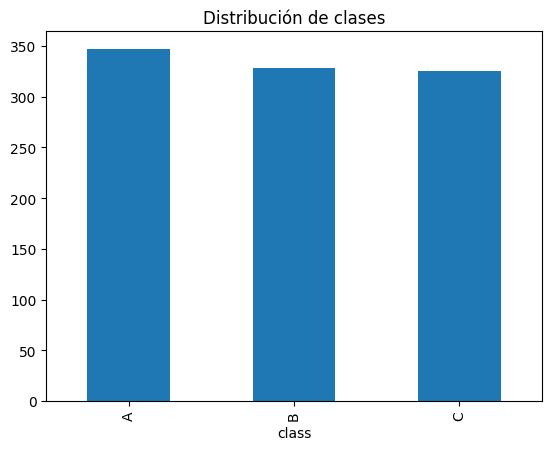

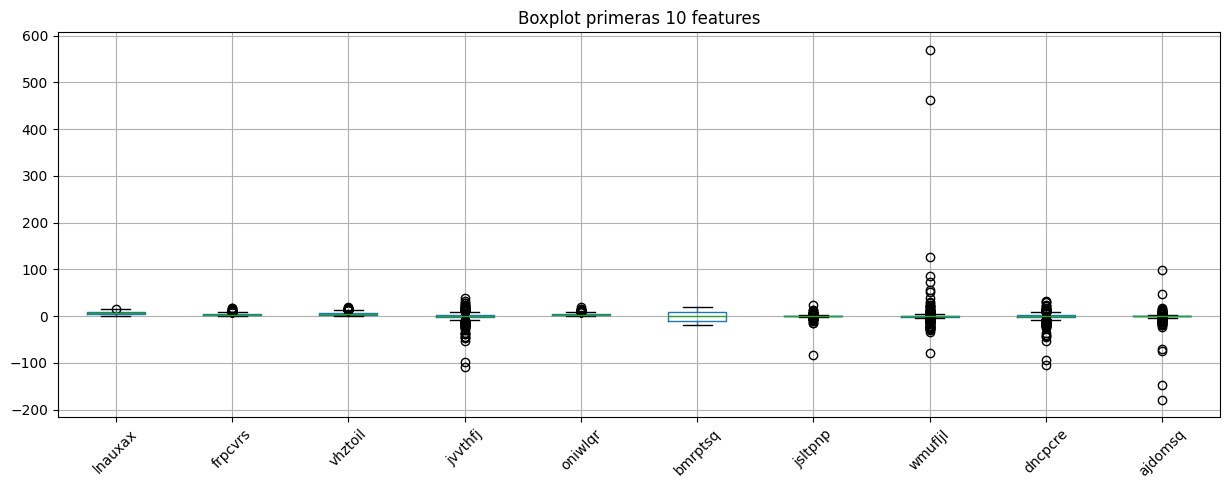

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribución de clases
print(y.value_counts())
y.value_counts().plot(kind='bar')
plt.title("Distribución de clases")
plt.show()

# 2. Outliers - boxplot de algunas features
X.iloc[:, :10].boxplot(figsize=(15, 5))
plt.title("Boxplot primeras 10 features")
plt.xticks(rotation=45)
plt.show()

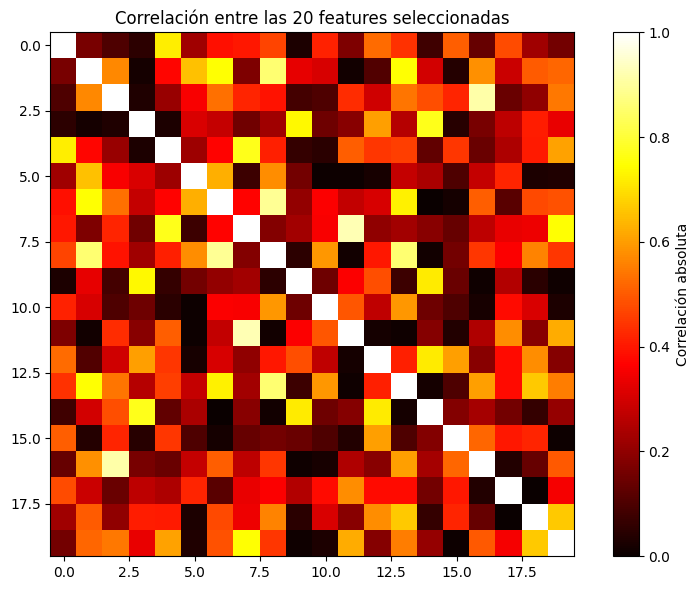

Correlación media entre features: 0.151


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Ver correlación entre features seleccionadas
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

pt = PowerTransformer()
skb = SelectKBest(mutual_info_classif, k=20)

X_t = pt.fit_transform(X)
X_sel = skb.fit_transform(X_t, y)

corr = np.corrcoef(X_sel.T)
plt.figure(figsize=(8,6))
plt.imshow(np.abs(corr), cmap="hot", vmin=0, vmax=1)
plt.colorbar(label="Correlación absoluta")
plt.title("Correlación entre las 20 features seleccionadas")
plt.tight_layout()
plt.show()

print(f"Correlación media entre features: {np.abs(np.triu(corr,1)).mean():.3f}")

In [5]:
# Info básica del dataset
print(f"Muestras      : {X.shape[0]}")
print(f"Features      : {X.shape[1]}")
print(f"Clases        : {np.unique(y)}")
print(f"Dist. clases  : {dict(zip(*np.unique(y, return_counts=True)))}")

Muestras      : 1000
Features      : 609
Clases        : ['A' 'B' 'C']
Dist. clases  : {'A': np.int64(347), 'B': np.int64(328), 'C': np.int64(325)}


La alta dimensionalidad del dataset, donde el número de features supera ampliamente al número de muestras por clase, impone restricciones importantes sobre qué modelos son aplicables. E

### NAIVE BAYES

In [ ]:
train = pd.read_csv("train.csv")
X = train.drop(columns=["class"])
y = train["class"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.model_selection import cross_validate

def evaluate(model, X, y):

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    
    val_mean = scores["test_score"].mean()
    val_std = scores["test_score"].std()
    train_mean = scores["train_score"].mean()

    return val_mean, val_std, train_mean

#### GAUSSIAN NAIVE BAYES - simple

 GAUSSIAN NAIVE BAYES - simple

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

nb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])

mean, std, train = evaluate(nb_pipe, X, y)
print(f"Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

El modelo obtuvo:

Train=0.6392
CV=0.5390±0.0377

lo que indica un rendimiento claramente inferior al de otros modelos evaluados.

Posteriormente se estudió el efecto del hiperparámetro var_smoothing, que introduce una regularización sobre las varianzas estimadas para evitar problemas numéricos cuando alguna variable presenta varianza muy pequeña.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

for vs in [1e-9, 1e-7, 1e-5, 1e-3, 1e-1]:
    nb = Pipeline([
        ("scaler", StandardScaler()),
        ("nb", GaussianNB(var_smoothing=vs))
    ])
    mean, std, train = evaluate(nb, X, y)
    print(f"var_smoothing={vs} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")


Resultado: no ayuda nada — el problema no era la varianza sino que las distribuciones no eran normales.

Naive Bayes: Optimización mediante Transformación de Potencia y Selección de Atributos

PowerTransformer + SelectKBest Estudiamos dos cosas a la vez: transformar las variables hacia la normalidad y reducir dimensionalidad. Resultado: sube a CV 0.651,  el salto viene de seleccionar pocas variables relevantes

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PowerTransformer
from sklearn.naive_bayes import GaussianNB

for k in [10, 20, 40, 60, 80, 100]:

    nb_mejorado = make_pipeline(
        PowerTransformer(),
        SelectKBest(f_classif, k=k),
        GaussianNB(var_smoothing=1e-5)
    )

    mean, std, train = evaluate(nb_mejorado, X, y)

    print(f"k={k} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

Este paso estudia si PCA como reductor de dimensionalidad mejora el modelo en vez de SelectKBest.

In [ ]:
# 1. PowerTransformer: Normaliza la distribución de cada variable.
# 2. PCA: Reduce 610 variables a las más importantes e independientes.
# 3. GaussianNB: Clasifica sobre los componentes limpios.

nb_pca = make_pipeline(
    PowerTransformer(),
    PCA(n_components=50), # Probamos con 50 componentes principales
    GaussianNB()
)

mean, std, train = evaluate(nb_pca, X, y)
print(f"Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

PCA crea componentes que maximizan varianza, no discriminación entre clases. Las 50 componentes con más varianza no son necesariamente las más útiles para clasificar. SelectKBest en cambio selecciona directamente las variables más discriminantes.

QuantileTransformer vs PowerTransformer Estudiamos qué transformador normaliza mejor. QuantileTransformer fuerza normalidad exacta, PowerTransformer solo la aproxima. Resultado: QuantileTransformer claramente mejor (0.754 vs 0.651).

In [ ]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline

# Fijamos k=10 que fue el mejor
for name, scaler in [
    ("PowerTransformer",   PowerTransformer()),
    ("QuantileTransformer", QuantileTransformer(output_distribution="normal", random_state=42)),
]:
    nb = make_pipeline(scaler, SelectKBest(f_classif, k=10), GaussianNB())
    mean, std, train = evaluate(nb, X, y)
    print(f"{name} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")


El mejor modelo de Naive Bayes hasta ahora es:

QuantileTransformer + SelectKBest(f_classif, k=10) + GaussianNB

Afinamos más el k probando diferentes valores y diferentes criterios para refinar


In [ ]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline

for k in [20, 25, 30, 35, 40, 50, 100, 200, 300, "all"]:
    nb = make_pipeline(
        QuantileTransformer(output_distribution="normal", random_state=42),
        SelectKBest(f_classif, k=k),
        GaussianNB()
    )
    mean, std, train = evaluate(nb, X, y)
    print(f"f_classif k={k} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")



El óptimo es k=30 (CV: 0.790) o k=50 (CV: 0.793), prácticamente iguales A partir de k=100 el rendimiento cae y el sobreajuste aumenta Con "all" (609 variables) Train sube a 0.843 pero CV baja a 0.758, overfitting claro

In [ ]:
import matplotlib.pyplot as plt

k_values = [20, 25, 30, 35, 40, 50, 100, 200, 300, 609]
labels =   [20, 25, 30, 35, 40, 50, 100, 200, 300, "all"]

train_scores = [0.7852, 0.7887, 0.7913, 0.7908, 0.7935, 0.7993, 0.7910, 0.8025, 0.8177, 0.8430]
cv_scores =    [0.7850, 0.7860, 0.7900, 0.7840, 0.7870, 0.7930, 0.7860, 0.7730, 0.7700, 0.7580]
cv_std =       [0.0164, 0.0159, 0.0130, 0.0097, 0.0150, 0.0209, 0.0231, 0.0223, 0.0217, 0.0121]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(len(k_values)), train_scores, marker="o", color="#E07B39", label="Train")
ax.plot(range(len(k_values)), cv_scores, marker="o", color="#378ADD", label="CV")
ax.fill_between(
    range(len(k_values)),
    [cv - s for cv, s in zip(cv_scores, cv_std)],
    [cv + s for cv, s in zip(cv_scores, cv_std)],
    alpha=0.15, color="#378ADD"
)

best_idx = cv_scores.index(max(cv_scores))
ax.axvline(x=best_idx, color="red", linestyle="--", alpha=0.6,
           label=f"óptimo k={labels[best_idx]} (CV={max(cv_scores):.3f})")

ax.set_xticks(range(len(k_values)))
ax.set_xticklabels(labels)
ax.set_xlabel("k (número de features)")
ax.set_ylabel("Accuracy")
ax.set_title("GaussianNB — efecto del número de variables (QuantileTransformer + f_classif)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0.74, 0.87)
plt.tight_layout()
plt.show()

MODELO FINAL 1

In [ ]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline

gnb_final = make_pipeline(
    QuantileTransformer(output_distribution="normal", random_state=42),
    SelectKBest(f_classif, k=50),
    GaussianNB()
)

mean, std, train = evaluate(gnb_final, X, y)
print(f"GNB final → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

#### NAIBE BAYES CATEGORICO

In [ ]:
import pandas as pd
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import make_pipeline

results = []

for n_bins in [3, 4, 5, 8, 10, 30, 40, 50, 100]:
    for k in [20, 30, 40, 50, 60, 100, 200, 300, "all"]:
        cnb = make_pipeline(
            KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile"),
            SelectKBest(f_classif, k=k),
            CategoricalNB()
        )
        mean, std, train = evaluate(cnb, X, y)
        results.append({
            "bins": n_bins,
            "k": k,
            "Train": round(train, 4),
            "CV mean": round(mean, 4),
            "± std": round(std, 4)
        })

df = pd.DataFrame(results)
display(df)

In [ ]:
# Top 10 configuraciones según accuracy de validación cruzada
top10 = df.sort_values("CV mean", ascending=False).head(10)

display(top10)

MODELO FINAL 2

In [ ]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import make_pipeline

cnb_final = make_pipeline(
    KBinsDiscretizer(n_bins=30, encode="ordinal", strategy="quantile"),
    SelectKBest(f_classif, k=60),
    CategoricalNB()
)

mean, std, train = evaluate(cnb_final, X, y)
print(f"CNB final → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

### ANALISIS DISCRIMINATORIO

#### LDA

Modelo más basico (base)

In [ ]:
lda_basic = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

lda_basic_score = evaluate(lda_basic, X, y)

print(f"Train accuracy: {lda_basic_score[0]:.4f}")
print(f"CV accuracy:    {lda_basic_score[1]:.4f} ± {lda_basic_score[2]:.4f}")



El primer modelo LDA sin regularización mostró un overfitting severo - Train=0.953 pero CV=0.399, apenas por encima del clasificador aleatorio (0.333). Esto se debe a que con 609 features y solo 1000 muestras, LDA no puede estimar bien la matriz de covarianza Σ - hay más parámetros que datos, la matriz es inestable y su inversa amplifica el ruido, haciendo que el modelo memorice casualidades del entrenamiento que no se repiten en datos nuevos.

Modelo base + Regularización shrinkage="auto"

In [ ]:
lda_shrink = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(
        shrinkage="auto",
        solver="lsqr"
    ))
])

lda_shrink_score = evaluate(lda_shrink, X, y)
print(f"Train accuracy: {lda_shrink_score[0]:.4f}")
print(f"CV accuracy:    {lda_shrink_score[1]:.4f} ± {lda_shrink_score[2]:.4f}")

Esto elimina las combinaciones más extremas que eran puro ruido y obliga al modelo a encontrar patrones más robustos y generalizables. Por eso el CV sube bastante, de 0.399 a 0.596. Pero creemos que aún lo podemos mejorar más.

PROBAMOS DIFERENTES INTENSIDADES DE REGULACIÓN ANTES DE CONTINUAR

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

models = {}

# 1. LDA weak shrinkage
models["LDA shrinkage 0.1"] = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.1))
])
# 2. LDA medium shrinkage
models["LDA shrinkage 0.5"] = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.5))
])
# 3. LDA strong shrinkage
models["LDA shrinkage 0.9"] = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.9))
])

for name in ["LDA shrinkage 0.1", "LDA shrinkage 0.5", "LDA shrinkage 0.9"]:
    model = models[name]
    train_score, val_score, val_std = evaluate(model, X, y)
    print(f"{name} → Train: {train_score:.4f} | CV: {val_score:.4f} ± {val_std:.4f}")



A medida que aumenta el shrinkage, el CV mejora consistentemente de 0.479 a 0.708, mientras el Train baja de 0.920 a 0.852,  señal clara de que la regularización está funcionando. Con shrinkage bajo el modelo se fía demasiado de la covarianza muestral, que con 609 features es inestable, y memoriza el entrenamiento sin generalizar. Al aumentar el shrinkage la matriz se estabiliza, el modelo pierde capacidad de memorizar y gana capacidad de generalizar. La tendencia ascendente del CV sugiere que el óptimo está por encima de 0.9, lo que justifica explorar valores más altos en el siguiente paso.

Vamos a probar un barrido más eshaustivo para los avlores de regularización

In [ ]:
models = {}

# SHRINKAGE GRID
for s in [0.1, 0.3, 0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 0.98, 1.0]:
    models[f"LDA shrinkage={s}"] = Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=s))
    ])


# EVALUATION
results = []
for name, model in models.items():
    train_score, val_score, val_std = evaluate(model, X, y)
    results.append([name, train_score, val_score, val_std])

# TABLE
results_df = pd.DataFrame(
    results,
    columns=["Model", "Train Accuracy", "CV Accuracy", "Std"]
)
results_df

Reveló que el óptimo se encuentra en shrinkage=0.98, con CV=0.719, punto a partir del cual el modelo empieza a sobre-regularizarse —, shrinkage=1.0 baja a 0.705 porque forzar una covarianza completamente diagonal ignora toda la estructura real de los datos.

En paralelo se probó PCA como alternativa de reducción de dimensionalidad previa a LDA, pero resultó contraproducente en todos los casos, confirmando que descartar componentes de baja varianza elimina información discriminante relevante para separar las tres clases.

In [ ]:
for n in [0.90, 0.95, 0.98, 0.99]:
    models[f"PCA={n} + LDA"] = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n)),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
    ])

# EVALUATION
results = []
for name, model in models.items():
    train_score, val_score, val_std = evaluate(model, X, y)
    results.append([name, train_score, val_score, val_std])

# TABLE
results_df = pd.DataFrame(
    results,
    columns=["Model", "Train Accuracy", "CV Accuracy", "Std"]
)
results_df

ANALISIS EXHASUTIVO

EMPEZAMOS A APLICAR SELECTKBEST

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, GridSearchCV

lda_power = Pipeline([
    ("power",    PowerTransformer()),
    ("selector", SelectKBest(score_func=f_classif)),
    ("lda",      LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.98))
])
param_grid = {"selector__k": [5, 10, 20, "all"]}
grid = GridSearchCV(lda_power, param_grid, cv=cv, scoring="accuracy")
grid.fit(X, y)

best_model = grid.best_estimator_
train_score = best_model.score(X, y)

train_acc, cv_acc, cv_std = evaluate(best_model, X, y)

print(f"Best k         : {grid.best_params_['selector__k']}")
print(f"Train accuracy : {train_acc:.4f}")
print(f"CV accuracy    : {cv_acc:.4f} ± {cv_std:.4f}")

Resultado muy interesante — con solo 20 features el modelo ya llega a CV=0.733, una mejora enorme respecto al LDA sin selector (CV=0.719). Lo más llamativo es que Train=0.737 y CV=0.733 son casi idénticos — el overfitting ha desaparecido casi por completo. Antes con 609 features teníamos Train=0.829 y CV=0.719, una brecha de 0.11. Ahora con 20 features la brecha es de solo 0.004. Esto confirma exactamente lo que esperábamos: el problema no era el modelo sino el ruido. 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler, RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

# Pipeline genérico con pasos intercambiables
pipe = Pipeline([
    ("scaler",   PowerTransformer()),
    ("reduce",   SelectKBest()),
    ("lda",      LinearDiscriminantAnalysis(solver="lsqr"))
])

param_grid = [
    # Rama 1: SelectKBest con distintas métricas y k
    {
        "scaler":           [StandardScaler(), RobustScaler()],
        "reduce":           [SelectKBest(f_classif), SelectKBest(mutual_info_classif)],
        "reduce__k":        [5, 10, 15, 20, 25, 30, "all"],
        "lda__shrinkage":   [0.0, 0.3, 0.5, 0.7, 0.9, 0.95, 0.98, 1.0],
    },
    # Rama 2: PCA
    {
        "scaler":           [StandardScaler(), RobustScaler()],
        "reduce":           [PCA()],
        "reduce__n_components": [0.80, 0.90, 0.95, 0.99],
        "lda__shrinkage":   [0.0, 0.3, 0.5, 0.7, 0.9, 0.95, 0.98, 1.0],
    },
]

grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy")
grid.fit(X, y)

best_model = grid.best_estimator_
train_acc, cv_acc, cv_std = evaluate(best_model, X, y)

print(f"\nBest config     : {grid.best_params_}")
print(f"Train accuracy  : {train_acc:.4f}")
print(f"CV accuracy     : {cv_acc:.4f} ± {cv_std:.4f}")

In [ ]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

top10 = results.sort_values("mean_test_score", ascending=False).head(10)

table = pd.DataFrame({
    "Rank": top10["rank_test_score"].values,
    "CV": top10["mean_test_score"].round(4).values,
    "Std": top10["std_test_score"].round(4).values,
    "Scaler": [type(p["scaler"]).__name__ for p in top10["params"]],
    "Reduce": [type(p["reduce"]).__name__ for p in top10["params"]],
    "k / PCA": [
        p.get("reduce__k", p.get("reduce__n_components", "-"))
        for p in top10["params"]
    ],
    "Shrinkage": [p["lda__shrinkage"] for p in top10["params"]],
})

table

In [ ]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

top = results.sort_values("mean_test_score", ascending=False).head(100)

plt.figure(figsize=(10,5))
plt.plot(top["mean_test_score"].values, marker="o")
plt.xlabel("Top modelos (ordenados)")
plt.ylabel("CV accuracy")
plt.title("Techo del rendimiento: saturación del modelo")
plt.grid(True)
plt.show()

In [ ]:
plt.figure()
plt.hist(results["mean_test_score"], bins=30)
plt.xlabel("CV accuracy")
plt.ylabel("Número de modelos")
plt.title("Distribución de rendimiento (evidencia de techo)")
plt.grid(True)
plt.show()

Es decir, SelectKBest y shrinkage hacían trabajo solapado. Ambos combatían el mismo problema, la inestabilidad de Σ causada por demasiadas features ruidosas. Al eliminar el ruido con SelectKBest, el shrinkage ya no necesita ser tan agresivo y puede dejar más libertad al modelo para capturar la estructura discriminante real entre las clases.

MODELO FINAL

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, mutual_info_classif

lda_final = Pipeline([
    ("scaler",   PowerTransformer()),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=20)),
    ("lda",      LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.3))
])

train, mean, std = evaluate(lda_final, X, y)
print(f"LDA final → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")



#### QDA

Para poder aplicar Quadratic Discriminant Analysis (QDA) es necesario que la matriz de covarianza de cada clase sea invertible. Esto solo es posible si el número de muestras por clase es mayor que el número de features: N_c > p.

En este caso, p = 609, pero cada clase tiene alrededor de 300 muestras, por lo que N_c < p. Esto implica que las matrices de covarianza son singulares (no invertibles) y QDA no puede aplicarse directamente.

In [ ]:

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

results_qda = []

for reg in [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]:
    qda = Pipeline([
        ("scaler", StandardScaler()),
        ("qda", QuadraticDiscriminantAnalysis(reg_param=reg))
    ])
    train_score, val_score, val_std = evaluate(qda, X, y)
    results_qda.append([f"QDA reg={reg}", train_score, val_score, val_std])

results_qda_df = pd.DataFrame(
    results_qda,
    columns=["Model", "Train Accuracy", "CV Accuracy", "Std"]
)
results_qda_df



Para que QDA funcione necesitaríamos reducir p hasta que se cumpla Nc > p. Con las muestras que tenemos, la condición más restrictiva es la clase C con 325 muestras, así que necesitaríamos p < 325, es decir, quedarnos con menos de 325 features.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

# Nc mínimo = 325 (clase C), necesitamos p < 325
# Probamos varios valores de n_components para ver cuál funciona mejor
results_qda_pca = []

for n in [50, 100, 150, 200, 250, 300, 320]:
    qda_pca = Pipeline([
        ("scaler",   PowerTransformer()),
        ("pca",      PCA(n_components=n)),
        ("qda",      QuadraticDiscriminantAnalysis())
    ])
    evaluate(qda_pca, X, y)
    results_qda_pca.append([
        f"PCA(n={n}) + QDA",
        round(train_score, 4),
        round(val_score, 4),
        round(val_std, 4)
    ])
    print(f"n={n} → Train: {train_score:.4f} | CV: {val_score:.4f} ± {val_std:.4f}")

pd.DataFrame(results_qda_pca, columns=["Model", "Train", "CV", "Std"])



A medida que subes n, QDA tiene más dimensiones para memorizar el entrenamiento — Train sube hasta 1.0 perfecto — pero CV se desploma porque la estimación se vuelve cada vez más inestable al acercarse al límite Nc > p.

Podrimaos meter una pqeuña regulariacion adicional

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

results_qda_reg = []

for n in [30, 40, 50, 60, 70]:
    for reg in [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]:
        qda = Pipeline([
            ("scaler", PowerTransformer()),
            ("pca",    PCA(n_components=n)),
            ("qda",    QuadraticDiscriminantAnalysis(reg_param=reg))
        ])
        val_score, val_std, train_score = evaluate(qda, X, y)
        results_qda_reg.append([
            n, reg,
            round(train_score, 4),
            round(val_score, 4),
            round(val_std, 4)
        ])

df_qda = pd.DataFrame(results_qda_reg, columns=["n_components", "reg_param", "Train", "CV", "Std"])
df_qda.sort_values("CV", ascending=False).head(10)

El mejor QDA llega a CV=0.706 con n=30 y reg_param=0.5, que sigue sin superar al LDA final (CV=0.733). Además necesita mucha regularización para no colapsar, lo que confirma que QDA sigue siendo inestable incluso después del PCA.

### BAGGING

In [ ]:
train = pd.read_csv("train.csv")
X = train.drop(columns=["class"])
y = train["class"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.model_selection import cross_validate

from sklearn.model_selection import cross_validate

def evaluate(model, X, y):

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    train_mean = scores["train_score"].mean()
    val_mean = scores["test_score"].mean()
    val_std = scores["test_score"].std()

    return val_mean, val_std, train_mean



Los 4 parámetros del BaggingClassifier:

- max_depth: profundidad del árbol base, controla cuánto aprende cada modelo individual
- n_estimators: cuántos árboles entrena el bagging 
- max_samples: qué porcentaje del dataset ve cada árbol 
- max_features: qué porcentaje de features usa cada árbol 


DecisionTree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

cv_fix = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tree_base = DecisionTreeClassifier(random_state=42)
scores = cross_validate(tree_base, X, y, cv=cv_fix, scoring="accuracy", return_train_score=True)
print(f"Decision Tree sin bagging → Train: {scores['train_score'].mean():.4f} | CV: {scores['test_score'].mean():.4f} ± {scores['test_score'].std():.4f}")

Vamos a explorar el efecto de nestimators y maxsamples en un BaggingClassifier con árbol de decisión sin restricciones, usando todas las features. El objetivo es entender cómo el número de modelos y el tamaño de cada muestra afectan al rendimiento.

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

for n_estimators in [50, 100, 200]:
    for max_samples in [0.5, 0.7, 1.0]:
        bag = BaggingClassifier(
            estimator=DecisionTreeClassifier(),
            n_estimators=n_estimators,
            max_samples=max_samples,
            max_features=1.0,  
            random_state=42,
            n_jobs=-1
        )
        mean, std, train = evaluate(bag, X, y)
        print(f"n={n_estimators} samples={max_samples} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

Fijamos n_estimators=100 y max_samples=0.7 y ahora exploramos el efecto de max_features: cuántas features ve cada árbol, probando desde el 10% hasta la raíz cuadrada del total. El objetivo es ver cuánta aleatoriedad en las features beneficia al modelo.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
import numpy as np

n_features = X.shape[1]  

for max_features in [0.1, 0.2, 0.3, 0.5, int(np.sqrt(n_features))]:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100,
        max_samples=0.7,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    mean, std, train = evaluate(bag, X, y)
    print(f"feat={max_features} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

Fijamos los mejores valores hasta ahora (n_estimators=100, max_samples=0.7, max_features=0.1) e introducimos max_depth para controlar la complejidad del árbol base. El objetivo es encontrar el equilibrio entre un árbol demasiado simple (underfitting) y uno que memorice (overfitting).

In [ ]:
for max_depth in [3, 5, 7, 10, 15, 20, 100]:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=max_depth, random_state=42),
        n_estimators=100,
        max_samples=0.7,
        max_features=0.1,
        random_state=42,
        n_jobs=-1
    )
    mean, std, train = evaluate(bag, X, y)
    print(f"depth={max_depth} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

AFINAMOS - decision tree

AFINAMOS MAX SAMPLES

In [ ]:

for max_samples in [0.6, 0.65, 0.7, 0.75, 0.8]:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=15, random_state=42),
        n_estimators=100,
        max_samples=max_samples,
        max_features=0.1,
        random_state=42,
        n_jobs=-1
    )
    mean, std, train = evaluate(bag, X, y)
    print(f"samples={max_samples} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

In [ ]:
for max_samples in [0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68]:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=15, random_state=42),
        n_estimators=100,
        max_samples=max_samples,
        max_features=0.1,
        random_state=42,
        n_jobs=-1
    )
    mean, std, train = evaluate(bag, X, y)
    print(f"samples={max_samples} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

AFINAMOS MAX FEATURES

In [ ]:
for max_features in [0.05, 0.08, 0.1, 0.12, 0.15]:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=15, random_state=42),
        n_estimators=100,
        max_samples=0.65,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    mean, std, train = evaluate(bag, X, y)
    print(f"feat={max_features} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")



AFINAMOS MAX_DEPTH

In [ ]:
depths = [3, 5, 7, 8, 9, 10, 12, 15, 20, None]

results = []
for d in depths:
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=d, random_state=42),
        n_estimators=100,
        max_samples=0.65,
        max_features=0.1,
        random_state=42,
        n_jobs=-1
    )
    mean, std, train = evaluate(model, X, y)
    results.append((d, train, mean, std))
    label = str(d) if d is not None else "None"
    print(f"depth={label:>4} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

MODELO FINAL - decision tree

In [ ]:
bagging_final = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=15, random_state=42),
    n_estimators=100,
    max_samples=0.65,
    max_features=0.1,
    random_state=42,
    n_jobs=-1
)

mean, std, train = evaluate(bagging_final, X, y)
print(f"Bagging final → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

LDA

El modelo LDA final ya presenta un rendimiento estable con una baja varianza, por lo que la aplicación de bagging no produce mejoras significativas en precisión. 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, mutual_info_classif

lda_final = Pipeline([
    ("scaler",   PowerTransformer()),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=20)),
    ("lda",      LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.3))
])

mean, std, train = evaluate(lda_final, X, y)
print(f"LDA final → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

In [ ]:
from sklearn.ensemble import BaggingClassifier

bagging_lda = BaggingClassifier(
    estimator=lda_final,   
    n_estimators=100,
    max_samples=0.7,
    max_features=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

mean, std, train = evaluate(bagging_lda, X, y)

print(f"Bagging + LDA → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")



In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for n in [50, 100, 200, 300]:
    for s in [0.5, 0.7, 1.0]:
        for f in [0.3, 0.5, 1.0]:

            model = BaggingClassifier(
                estimator=lda_final,   
                n_estimators=n,
                max_samples=s,
                max_features=f,
                bootstrap=True,
                random_state=42,
                n_jobs=-1
            )

            scores = cross_validate(
                model,
                X,
                y,
                cv=cv_strategy,
                scoring="accuracy",
                return_train_score=True
            )

            train = scores["train_score"].mean()
            cv_mean = scores["test_score"].mean()
            cv_std = scores["test_score"].std()

            results.append([n, s, f, train, cv_mean, cv_std])

            print(f"n={n}, s={s}, f={f} → CV={cv_mean:.4f} ± {cv_std:.4f}")

- n=50, s=0.5, f=0.3 → CV=0.7670 ± 0.0236
- n=50, s=0.5, f=0.5 → CV=0.7620 ± 0.0248
- n=50, s=0.5, f=1.0 → CV=0.7690 ± 0.0193
- n=50, s=0.7, f=0.3 → CV=0.7630 ± 0.0254
- n=50, s=0.7, f=0.5 → CV=0.7630 ± 0.0250
- n=50, s=0.7, f=1.0 → CV=0.7660 ± 0.0265
- n=50, s=1.0, f=0.3 → CV=0.7640 ± 0.0263
- n=50, s=1.0, f=0.5 → CV=0.7610 ± 0.0280
- n=50, s=1.0, f=1.0 → CV=0.7650 ± 0.0217
- n=100, s=0.5, f=0.3 → CV=0.7640 ± 0.0317
- n=100, s=0.5, f=0.5 → CV=0.7670 ± 0.0294
- n=100, s=0.5, f=1.0 → CV=0.7660 ± 0.0203
- n=100, s=0.7, f=0.3 → CV=0.7620 ± 0.0289
- n=100, s=0.7, f=0.5 → CV=0.7700 ± 0.0310
- n=100, s=0.7, f=1.0 → CV=0.7630 ± 0.0262
- n=100, s=1.0, f=0.3 → CV=0.7610 ± 0.0282
- n=100, s=1.0, f=0.5 → CV=0.7670 ± 0.0250
- n=100, s=1.0, f=1.0 → CV=0.7640 ± 0.0203
- n=200, s=0.5, f=0.3 → CV=0.7620 ± 0.0314
- n=200, s=0.5, f=0.5 → CV=0.7640 ± 0.0262

### RANDOM FOREST

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

train = pd.read_csv("train.csv")
X = train.drop(columns=["class"])
y = train["class"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.model_selection import cross_validate

def evaluate(model, X, y):

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )
    val_mean = scores["test_score"].mean()
    val_std = scores["test_score"].std()
    train_mean = scores["train_score"].mean()

    return val_mean, val_std, train_mean    



In [ ]:
from sklearn.ensemble import RandomForestClassifier

for n_estimators in [100, 200, 300]:
    for max_depth in [None, 10, 20]:
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )
        mean, std, train = evaluate(rf, X, y)
        print(f"n={n_estimators} depth={max_depth} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

In [ ]:
from sklearn.ensemble import RandomForestClassifier

for max_features in ["sqrt", "log2", 0.3]:
    for min_samples_leaf in [1, 3, 5, 10]:
        rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            max_features=max_features,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        mean, std, train = evaluate(rf, X, y)
        print(f"feat={max_features} leaf={min_samples_leaf} → Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

ANALISIS EXHAUSTIVO

In [ ]:
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2", 0.3],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10, 20],
    "max_samples": [0.5, 0.7, 0.8, 1.0],
}

grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    n_iter=50,
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
grid.fit(X, y)

print(f"Mejor config: {grid.best_params_}")
print(f"Mejor CV: {grid.best_score_:.4f}")


# Gráfica de saturación
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)
top100 = results["mean_test_score"].sort_values(ascending=False).head(100).reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(top100, marker="o", markersize=3, color="#378ADD")
plt.axhline(y=grid.best_score_, color="red", linestyle="--", alpha=0.6,
            label=f"mejor CV = {grid.best_score_:.3f}")
plt.xlabel("Top modelos (ordenados)")
plt.ylabel("CV Accuracy")
plt.title("Techo del rendimiento — Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mejor config: {grid.best_params_}")
print(f"Mejor CV: {grid.best_score_:.4f}")

MODELO FINAL

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=10,
    min_samples_split=5,
    max_samples=1.0,
    criterion="gini",
    random_state=42,
    bootstrap=True
)

mean, std, train = evaluate(rf_final, X, y)
print(f"Train: {train:.4f} | CV: {mean:.4f} ± {std:.4f}")

### ADABOOST

In [ ]:
train = pd.read_csv("train.csv")
X = train.drop(columns=["class"])
y = train["class"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.model_selection import cross_validate

def evaluate(model, X, y):

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    train_mean = scores["train_score"].mean()
    val_mean = scores["test_score"].mean()
    val_std = scores["test_score"].std()

    return train_mean, val_mean, val_std



Los principales parametros son tres:

- n_estimators - cuántos stumps entrenar en secuencia. Más estimadores = más correcciones, pero a partir de cierto punto el modelo converge y añadir más no mejora. 
- learning_rate - cuánto contribuye cada modelo nuevo a la corrección. Hay un trade-off clásico con n_estimators: learning rate bajo necesita más estimadores para converger, learning rate alto converge antes pero puede sobreajustar.
- max_depth del estimador base - aunque técnicamente es un parámetro del árbol, en AdaBoost es crucial. Lo normal es max_depth=1 , pero a veces se prueba con 2 o 3 para darle más capacidad al modelo base.


MODELO BASE

Primero creamos un modelo base con (150 stumps, learning_rate=0.2) para tener un modelo de referencia y poder mejorarlo.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_base = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=150,
    learning_rate=0.2,
    random_state=42
)

train, cv_mean, cv_std = evaluate(ada_base, X, y)
print(f"AdaBoost baseline → Train: {train:.4f} | CV: {cv_mean:.4f} ± {cv_std:.4f}")

Primero vamos a buscar el max_depth óptimo del estimador base, que es el parámetro más impactante.

Es el parámetro más impactante porque afecta la capacidad base del ensemble entero. Si cada árbol aprende poco, necesitas muchos para llegar a un buen resultado. Si cada árbol aprende demasiado, el boosting pierde su ventaja y aparece overfitting.

In [ ]:
for depth in [1, 2, 3, 4, 5]:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=depth),
        n_estimators=150,
        learning_rate=0.2,
        random_state=42
    )
    train, cv_mean, cv_std = evaluate(ada, X, y)
    print(f"max_depth={depth} → Train: {train:.4f} | CV: {cv_mean:.4f} ± {cv_std:.4f}")

El problema es que a partir de max_depth=3 el árbol ya memoriza todo el train (1.0000) y las mejoras en CV son pequeñas. Con max_depth=5 el CV es el mejor pero el gap es enorme. Yo me quedaría con max_depth=2, es donde el CV da el salto más grandecon un overfitting todavía controlado.

Después de fijar el max_depth óptimo, el siguiente paso es ajustar n_estimators y learning_rate juntos, porque están acoplados.

In [ ]:
import numpy as np

lrs = [0.5, 0.2, 0.1, 0.05, 0.01]
ns = [100, 200, 300, 500, 1000]

print(f"{'lr':<8} {'n_est':<8} {'Train':>8} {'CV':>8} {'Gap':>8}")
print("-" * 45)

for lr in lrs:
    for n in ns:
        ada = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=2),
            n_estimators=n,
            learning_rate=lr,
            random_state=42
        )
        train, cv_mean, cv_std = evaluate(ada, X, y)
        print(f"lr={lr:<6} n={n:<6} {train:>8.4f} {cv_mean:>8.4f} {train-cv_mean:>8.4f}")
    print()

lr=0.5 n=1000 tiene CV=0.8000, apenas 0.001 más, pero con gap de 0.1875, no merece la pena.

Con lo que tenemos, me quedo con lr=0.1 y n=500:
CV = 0.7990,  el más alto de lr=0.1 Gap = 0.1562  razonable, no se dispara como con lr=0.5.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import make_pipeline

k_values = [10, 20, 30, 40, 50, 60]

print(f"{'k':<8} {'Train':>8} {'CV':>8} {'Gap':>8}")
print("-" * 35)

for k in k_values:
    pipe = make_pipeline(
        SelectKBest(f_classif, k=k),
        AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=2),
            n_estimators=500,
            learning_rate=0.1,
            random_state=42
        )
    )
    train, cv_mean, cv_std = evaluate(pipe, X, y)
    print(f"k={k:<6} {train:>8.4f} {cv_mean:>8.4f} {train-cv_mean:>8.4f}")

La mejor combinación fue lr=0.1 con n=500, que ofrecía el mejor CV sin disparar el overfitting como hacía lr=0.5. Por último se añadió SelectKBest para filtrar las features más relevantes, probando valores de k entre 10 y 60 y afinando entre 25 y 35. El valor óptimo fue k=30, que redujo el ruido de entrada y mejoró tanto el CV como el gap. El modelo final pasó de un CV de 0.7640 en el baseline a 0.8020, con un gap de solo 0.09.

Probamos a ver si con un criterio de SelectKbest cambia

In [ ]:
from sklearn.feature_selection import mutual_info_classif

pipe_mi = make_pipeline(
    SelectKBest(mutual_info_classif, k=30),
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=500,
        learning_rate=0.1,
        random_state=42
    )
)
train, cv_mean, cv_std = evaluate(pipe_mi, X, y)
print(f"mutual_info k=30 → Train: {train:.4f} | CV: {cv_mean:.4f} ± {cv_std:.4f}")

MODELO FINAL

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline

modelo_final_ada = make_pipeline(
    SelectKBest(f_classif, k=30),
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=500,
        learning_rate=0.1,
        random_state=42
    )
)

train, cv_mean, cv_std = evaluate(modelo_final_ada, X, y)
print(f"Modelo Final AdaBoost → Train: {train:.4f} | CV: {cv_mean:.4f} ± {cv_std:.4f}")



Modelo Final AdaBoost → Train: 0.8918 | CV: 0.8020 ± 0.0378

### GARDIENT BOOSTING

### STACKING